In [19]:
import uproot
import pandas as pd
import awkward as ak
import matplotlib.pyplot as plt

tables = [
    "O2upgradecascades",
    "O2upgradev0s"
]

def load_tables(filename, tables):
    data_dict = {}

    with uproot.open(filename) as f:
        keys = f.keys()
        print(f"Keys in {filename}: {keys}")

        for table in tables:
            matched_keys = [
                key for key in keys
                if len(key.split("/")) == 2
                and key.split("/")[1].split(";")[0] == table
            ]
            # matched_keys = [key for key in keys if table == key.split("/")[1].replace(";1", "") and len(key.split("/")) == 2]
            # matched_keys = [key for key in keys if table in key]

            if not matched_keys:
                print(f"No keys found for table: {table}")
                continue

            table_dfs = []

            for key in matched_keys:
                array = f[key].arrays(library="ak")

                if len(array) == 0:
                    print(f"Empty array for key: {key}")
                    continue

                data = {}
                for k in array.fields:
                    v = array[k]
                    
                    if isinstance(ak.type(v).content, ak.types.NumpyType):
                        # scalar branch
                        data[k] = ak.to_numpy(v)
                    else:
                        # vector branch
                        data[k] = ak.to_list(v)

                df = pd.DataFrame(data)

                if df.empty:
                    print(f"Empty DataFrame for key: {key}")
                    continue

                # optional but VERY useful: avoid duplicate column collisions
                df = df.add_prefix(f"{table}__")

                table_dfs.append(df)

            if table_dfs:
                data_dict[table] = pd.concat(table_dfs, ignore_index=True)
            else:
                print(f"No usable data for table: {table}")

    return data_dict


# Load datasets
df_before_mod = load_tables("/home/mdicosta/LocalTestsO2/OnTheFlyTracker/BeforeModifications/TreeReco.root", tables)
df_after_mod  = load_tables("/home/mdicosta/LocalTestsO2/OnTheFlyTracker/AfterModifications/TreeReco.root", tables)

Keys in /home/mdicosta/LocalTestsO2/OnTheFlyTracker/BeforeModifications/TreeReco.root: ['DF_391403000001;1', 'DF_391403000001/O2upgradecascades;1', 'DF_391403000001/O2upgradev0s;1', 'parentFiles;1']
Keys in /home/mdicosta/LocalTestsO2/OnTheFlyTracker/AfterModifications/TreeReco.root: ['DF_391403000001;1', 'DF_391403000001/O2upgradecascades;1', 'DF_391403000001/O2upgradev0s;1', 'parentFiles;1']


In [20]:
print("Data loaded successfully.")
print(f"keys df_before_mod: {df_before_mod.keys()}")
print(f"keys df_after_mod: {df_after_mod.keys()}")

Data loaded successfully.
keys df_before_mod: dict_keys(['O2upgradecascades', 'O2upgradev0s'])
keys df_after_mod: dict_keys(['O2upgradecascades', 'O2upgradev0s'])


In [21]:
df_after_mod["O2upgradecascades"][0:10]

,O2upgradecascades__fIndexCollisions,O2upgradecascades__fIndexTracks_Cascade,O2upgradecascades__fIndexTracks_Pos,O2upgradecascades__fIndexTracks_Neg,O2upgradecascades__fIndexTracks_Bach,O2upgradecascades__fDcaV0Daughters,O2upgradecascades__fDcaCascadeDaughters,O2upgradecascades__fV0Radius,O2upgradecascades__fCascRadius,O2upgradecascades__fCascRadiusMC,O2upgradecascades__fMLambda,O2upgradecascades__fMXi,O2upgradecascades__fFindableClusters,O2upgradecascades__fFoundClusters
0,38,1082,1081,1080,1079,0.011008,0.006228,3.286523,2.100520,2.106956,1.119440,1.334374,2,2
1,13,194,193,192,191,0.007409,0.006241,3.509618,1.763799,1.763552,1.115296,1.321363,2,2
2,31,952,951,950,949,0.007409,0.006241,3.509618,1.763799,1.763552,1.115296,1.321363,2,2
3,37,1289,1288,1287,1286,0.000001,0.040456,41.283428,3.641697,3.760003,1.115683,1.317990,3,3
4,22,417,416,415,414,0.003505,0.022674,12.662044,0.986266,0.957164,1.112504,1.332914,1,1
5,12,372,371,370,369,0.000002,0.006538,69.858711,5.061658,5.083903,1.115683,1.318913,3,3
6,23,791,790,789,788,0.022694,0.026716,3.580331,0.864956,0.827100,1.113920,1.319376,1,1
7,2,24,23,22,21,0.004102,0.002823,9.388635,6.577147,6.602836,1.115258,1.324191,3,3
8,19,526,525,524,523,0.002188,0.014218,4.738297,1.478055,1.420142,1.118746,1.323582,2,2
9,14,506,505,504,503,0.002761,0.035227,5.034295,3.412188,3.392905,1.117756,1.323941,3,3


In [22]:
df_before_mod["O2upgradecascades"][121:133]

,O2upgradecascades__fIndexCollisions,O2upgradecascades__fIndexTracks_Cascade,O2upgradecascades__fIndexTracks_Pos,O2upgradecascades__fIndexTracks_Neg,O2upgradecascades__fIndexTracks_Bach,O2upgradecascades__fDcaV0Daughters,O2upgradecascades__fDcaCascadeDaughters,O2upgradecascades__fV0Radius,O2upgradecascades__fCascRadius,O2upgradecascades__fCascRadiusMC,O2upgradecascades__fMLambda,O2upgradecascades__fMXi,O2upgradecascades__fFindableClusters,O2upgradecascades__fFoundClusters
121,35,1486,1485,1484,1483,0.005576,0.042403,3.806222,3.541534,3.575849,1.114341,1.322321,3,3
122,40,1218,1217,1216,1215,0.053880,0.084633,12.770000,1.649805,2.004533,1.116018,1.322653,2,2
123,24,479,478,477,476,0.000597,0.006985,21.578962,4.630651,4.618193,1.115579,1.323920,3,3
124,29,706,705,704,703,0.000061,0.000812,7.869004,7.101858,7.103489,1.117442,1.318784,4,4
125,48,1027,1026,1025,1024,0.062634,0.143472,2.994615,2.713948,2.846442,1.109359,1.323205,3,3
126,15,364,363,362,361,0.046363,0.012992,2.683482,1.996804,2.009947,1.112398,1.320679,2,2
127,41,1303,1302,1301,1300,0.000302,0.009183,3.749395,2.121921,2.082559,1.113745,1.326296,2,2
128,5,166,165,164,163,0.000002,0.000290,1.084665,0.965636,0.965320,1.115683,1.317624,1,1
129,47,1468,1467,1466,1465,0.000356,0.005156,8.269203,0.834559,0.858319,1.114824,1.323435,1,1
130,6,192,191,190,189,0.005353,0.000636,2.284163,1.624393,1.616694,1.115814,1.315477,2,2


In [23]:
df_after_mod["O2upgradev0s"][121:133]

,O2upgradev0s__fIndexCollisions,O2upgradev0s__fIndexV0s,O2upgradev0s__fIndexTracks_Pos,O2upgradev0s__fIndexTracks_Neg,O2upgradev0s__fDcaV0Daughters,O2upgradev0s__fV0Radius,O2upgradev0s__fMLambda,O2upgradev0s__fMAntiLambda,O2upgradev0s__fMK0,O2upgradev0s__fPt
121,13,2607,204,203,0.000138,4.718668,-1.000000,-1.000000,0.493157,2.342994
122,13,2607,204,203,0.000138,4.718668,-1.000000,-1.000000,0.493157,2.342994
123,13,2676,208,207,0.013207,2.836136,-1.000000,-1.000000,0.491170,2.256875
124,13,2724,210,209,0.002816,2.946955,-1.000000,-1.000000,0.497862,0.850684
125,13,2724,210,209,0.002816,2.946955,-1.000000,-1.000000,0.497862,0.850684
126,13,2794,214,213,0.001657,4.385224,-1.000000,1.117396,-1.000000,2.289074
127,14,3165,317,316,0.000207,1.107448,-1.000000,-1.000000,0.493922,0.644218
128,15,3397,329,328,0.000899,7.641768,-1.000000,-1.000000,0.498311,1.474331
129,15,3430,331,330,0.002187,1.636515,1.116578,-1.000000,-1.000000,0.481378
130,18,3853,365,364,0.000273,0.353708,-1.000000,-1.000000,0.494044,1.925575


In [24]:
df_before_mod["O2upgradev0s"][0:10]

,O2upgradev0s__fIndexCollisions,O2upgradev0s__fIndexV0s,O2upgradev0s__fIndexTracks_Pos,O2upgradev0s__fIndexTracks_Neg,O2upgradev0s__fDcaV0Daughters,O2upgradev0s__fV0Radius,O2upgradev0s__fMLambda,O2upgradev0s__fMAntiLambda,O2upgradev0s__fMK0,O2upgradev0s__fPt
0,2,369,28,27,0.000654,1.723260,-1.000000,-1.0,0.500532,0.277556
1,7,1306,91,90,0.015109,4.958477,-1.000000,-1.0,0.492335,0.470866
2,8,1679,125,124,0.002127,8.261858,-1.000000,-1.0,0.499349,1.589749
3,8,1757,143,142,0.023880,13.080388,-1.000000,-1.0,0.504119,1.390312
4,10,2168,151,150,0.004223,8.655672,-1.000000,-1.0,0.497210,0.574821
5,12,2809,215,214,0.000039,2.392282,-1.000000,-1.0,0.494853,0.563129
6,15,3389,253,252,0.001954,0.040619,1.116020,-1.0,-1.000000,0.227187
7,19,3877,285,284,0.000390,1.176766,-1.000000,-1.0,0.478547,0.574493
8,19,3900,289,288,0.000939,8.029031,-1.000000,-1.0,0.496632,0.434816
9,19,3975,300,299,0.000126,1.017969,1.116079,-1.0,-1.000000,0.454713


In [25]:
# Compare lengths of tables
for table in tables:
    len_before = len(df_before_mod.get(table, []))
    len_after = len(df_after_mod.get(table, []))
    print(f"Table: {table}, Before Modifications: {len_before} entries, After Modifications: {len_after} entries")

Table: O2upgradecascades, Before Modifications: 1390 entries, After Modifications: 1458 entries
Table: O2upgradev0s, Before Modifications: 154096 entries, After Modifications: 154130 entries


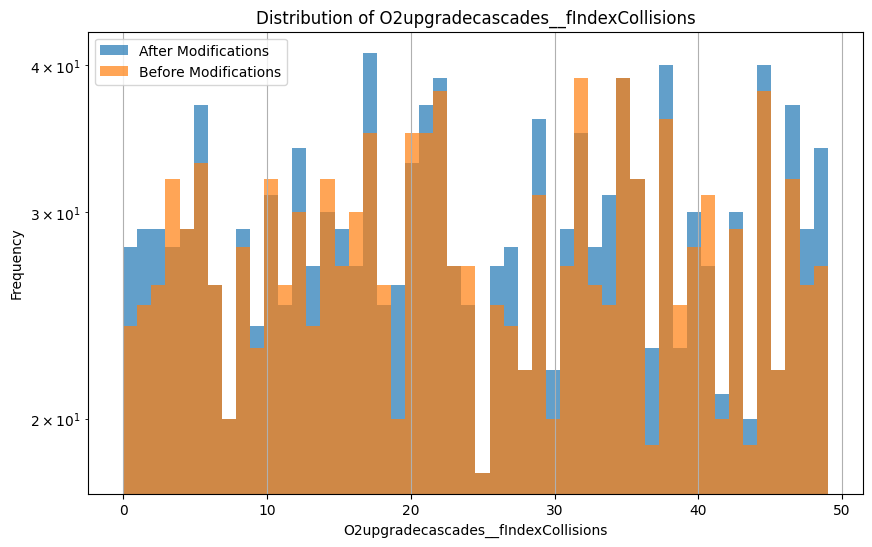

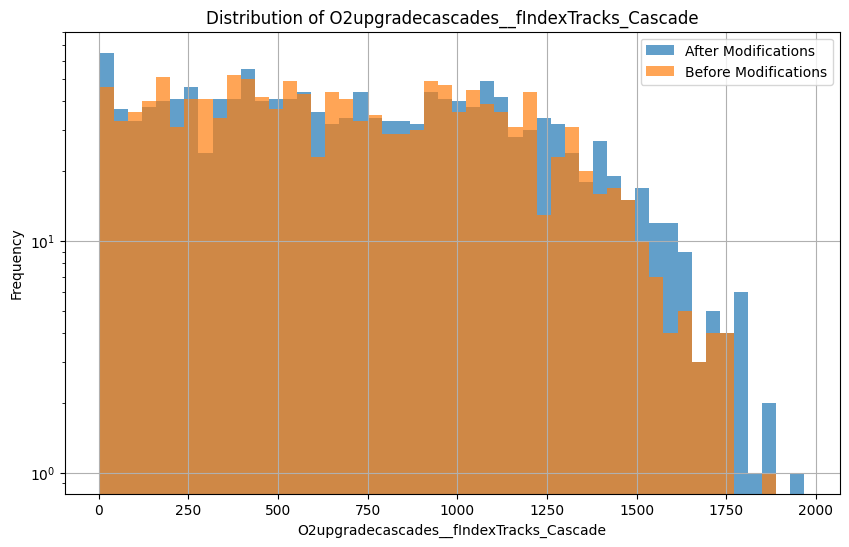

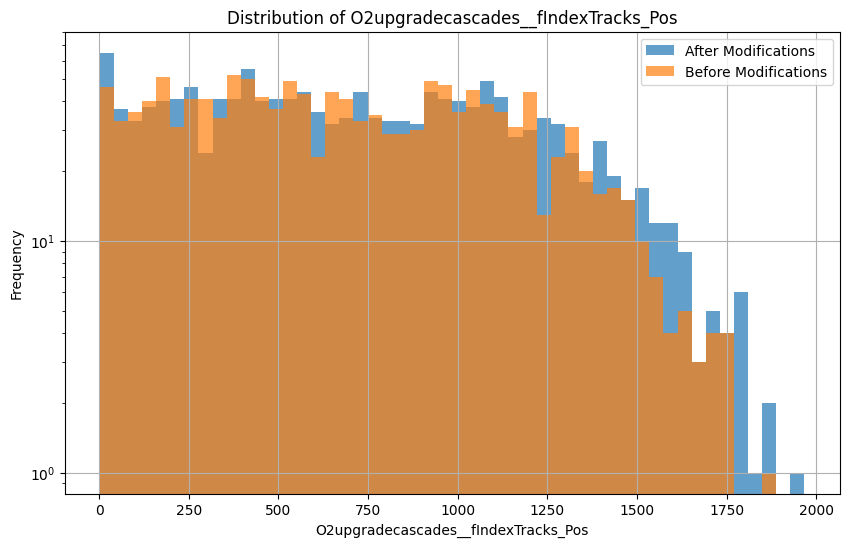

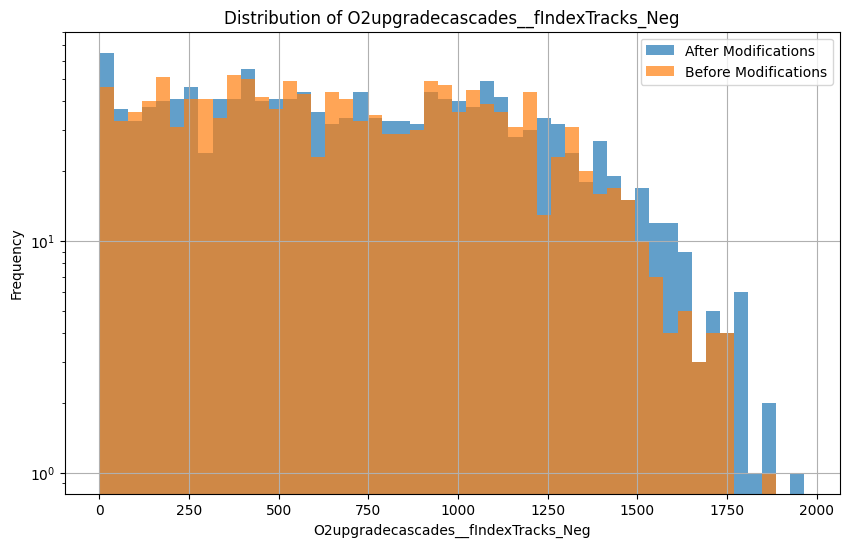

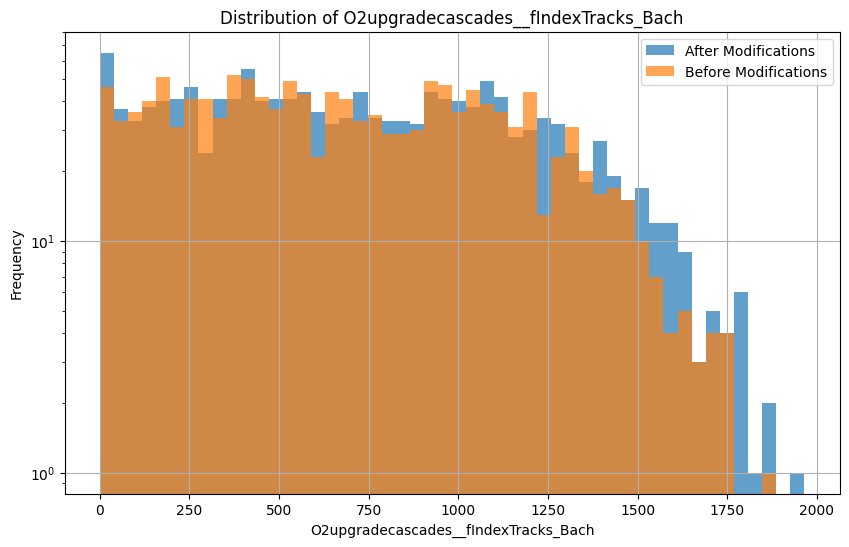

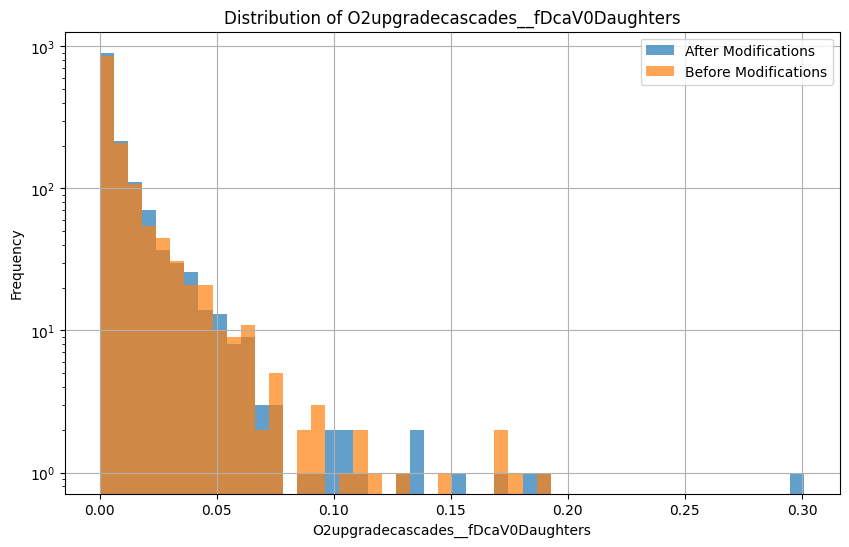

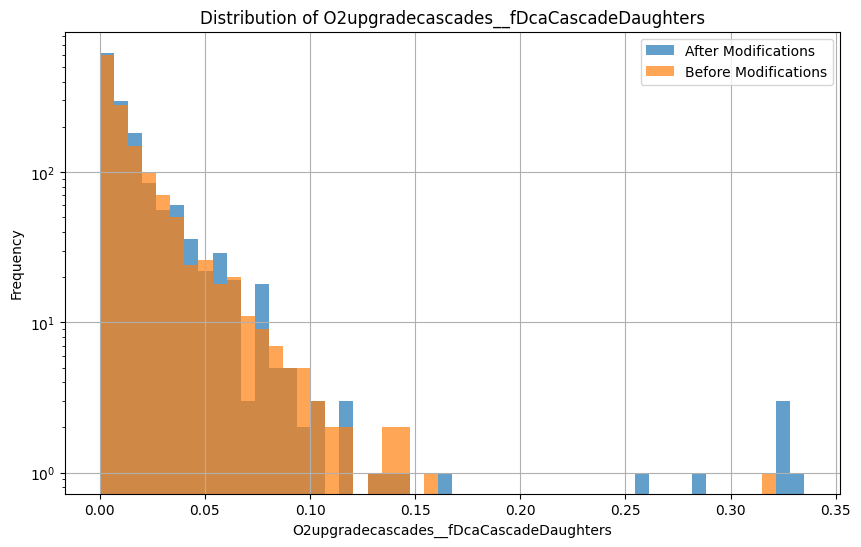

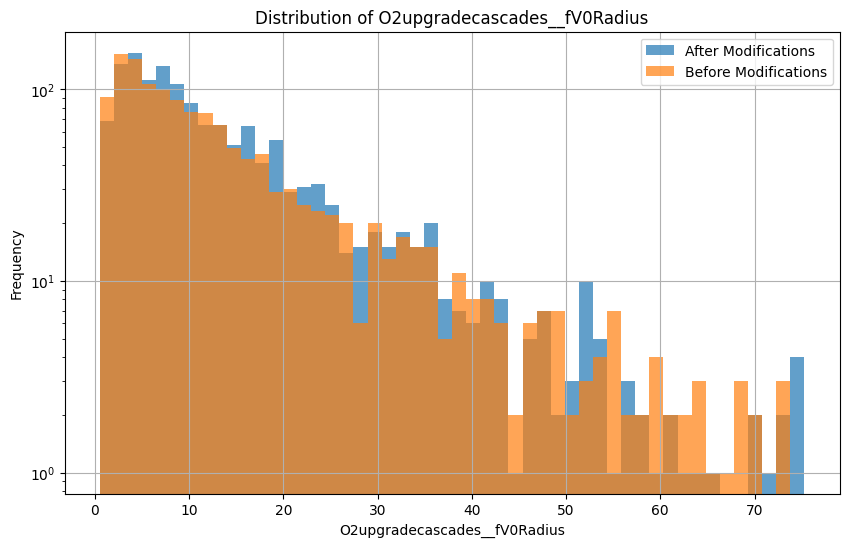

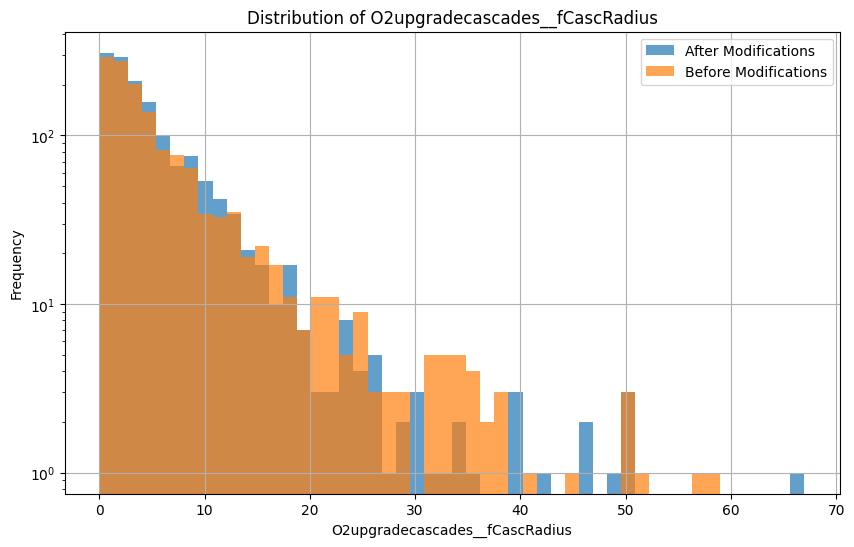

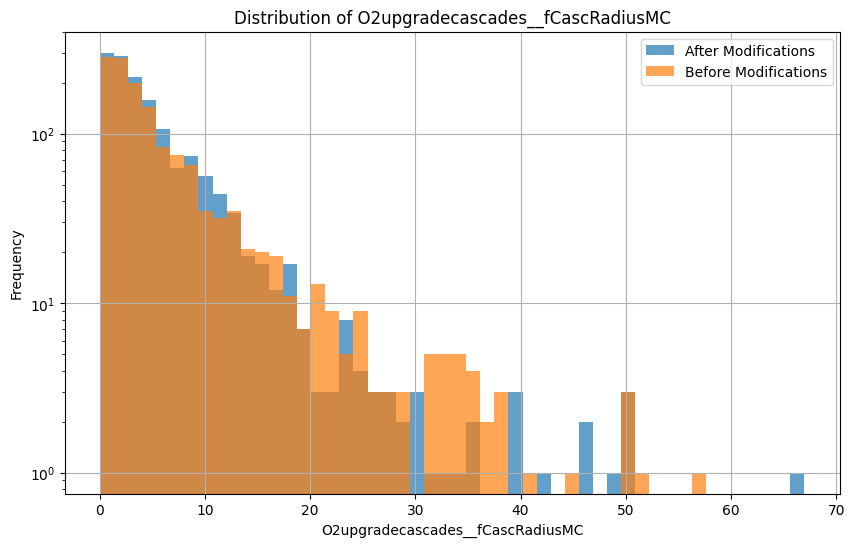

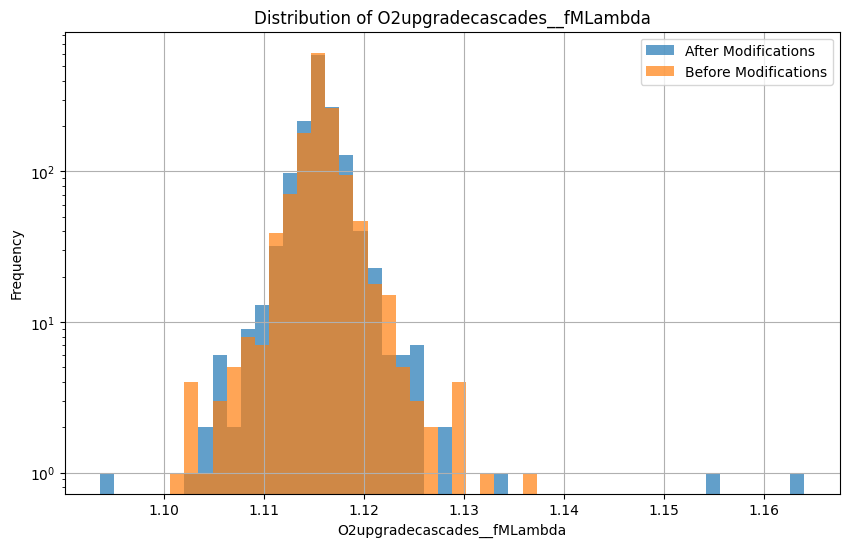

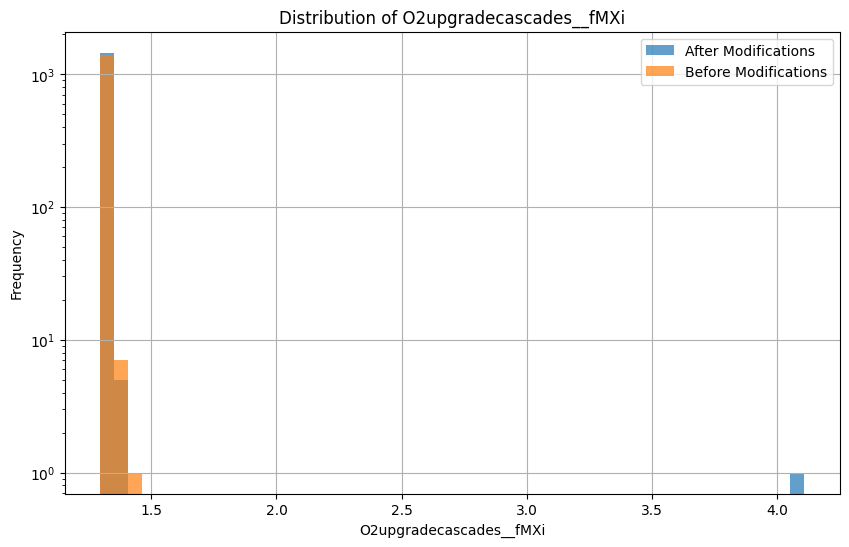

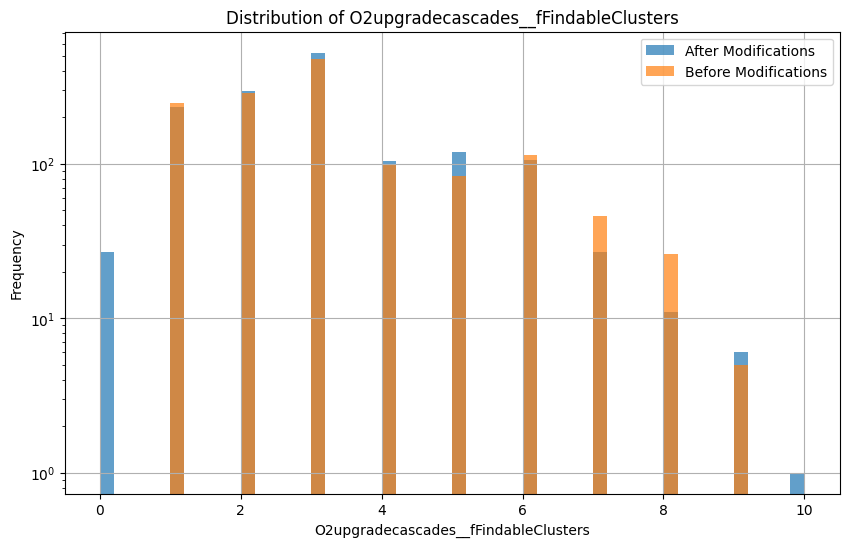

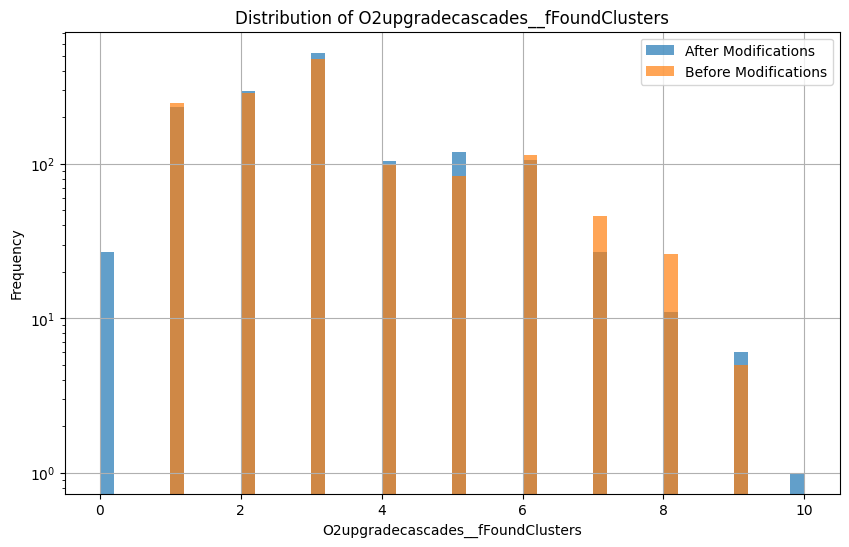

In [17]:
# Plot all columns of the cascades table
for column in df_after_mod["O2upgradecascades"].columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df_after_mod["O2upgradecascades"][column], bins=50, range=(df_after_mod["O2upgradecascades"][column].min(), df_after_mod["O2upgradecascades"][column].max()), alpha=0.7, log=True, label='After Modifications')
    plt.hist(df_before_mod["O2upgradecascades"][column], bins=50, range=(df_after_mod["O2upgradecascades"][column].min(), df_after_mod["O2upgradecascades"][column].max()), alpha=0.7, log=True, label='Before Modifications')
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()

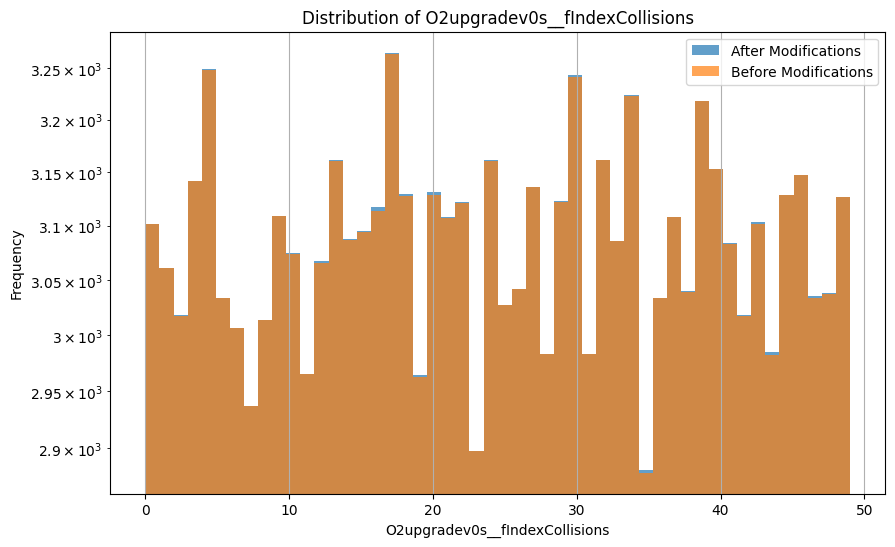

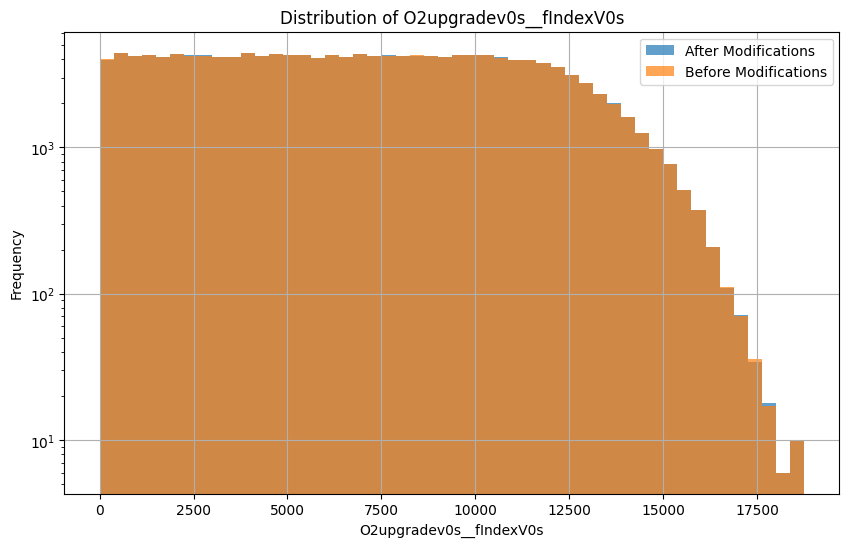

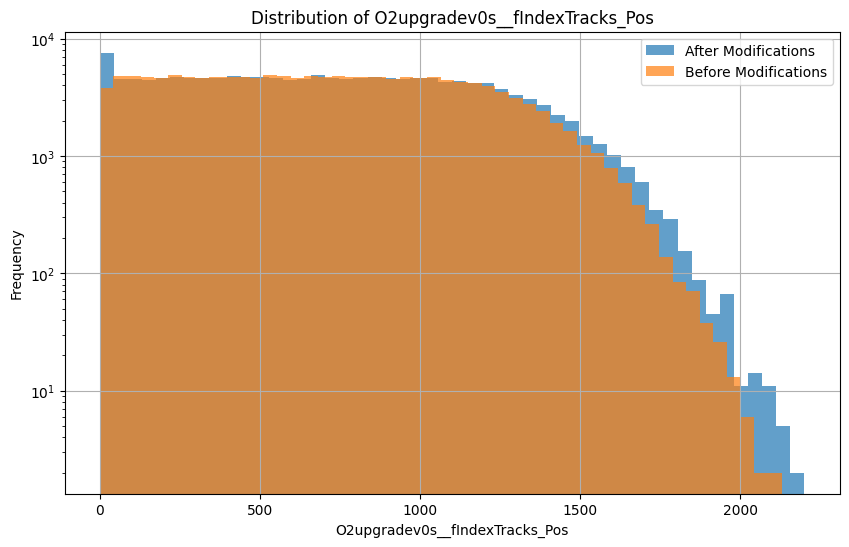

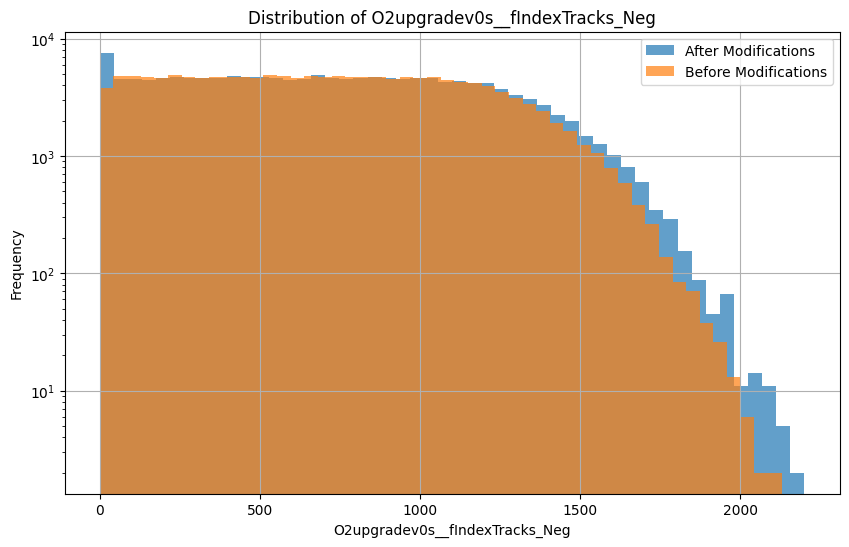

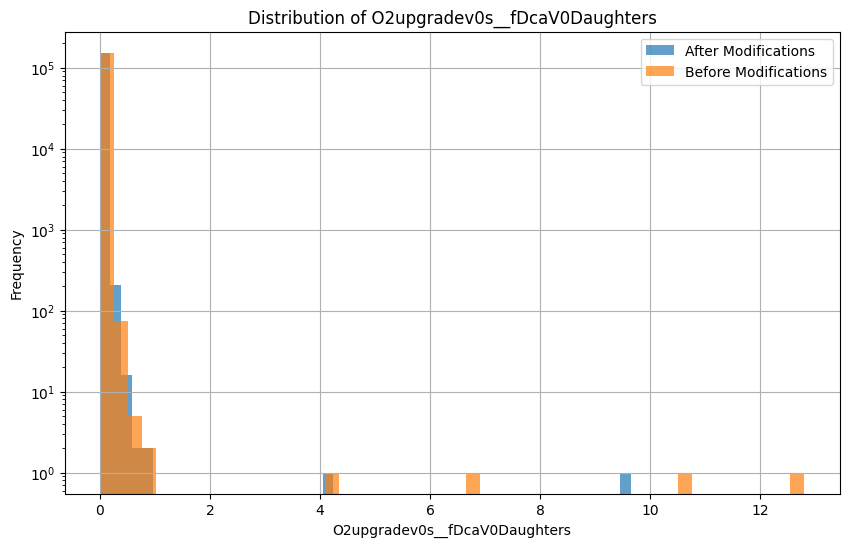

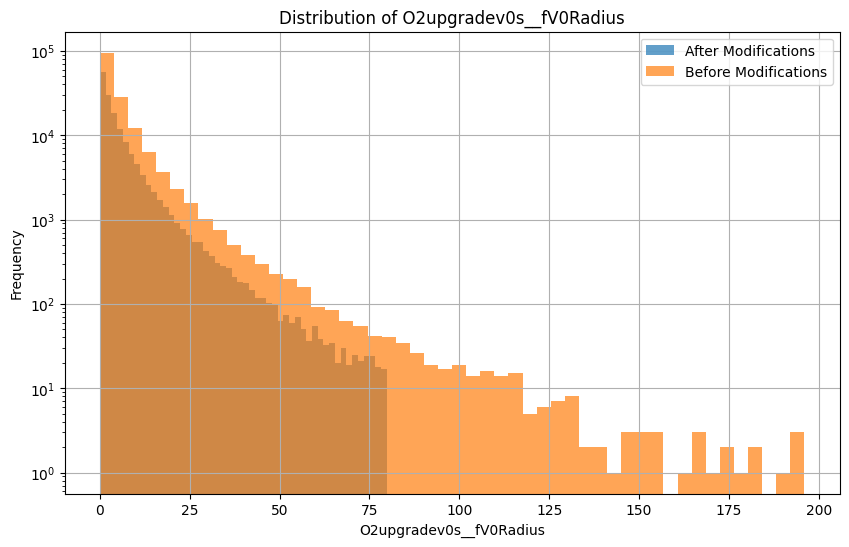

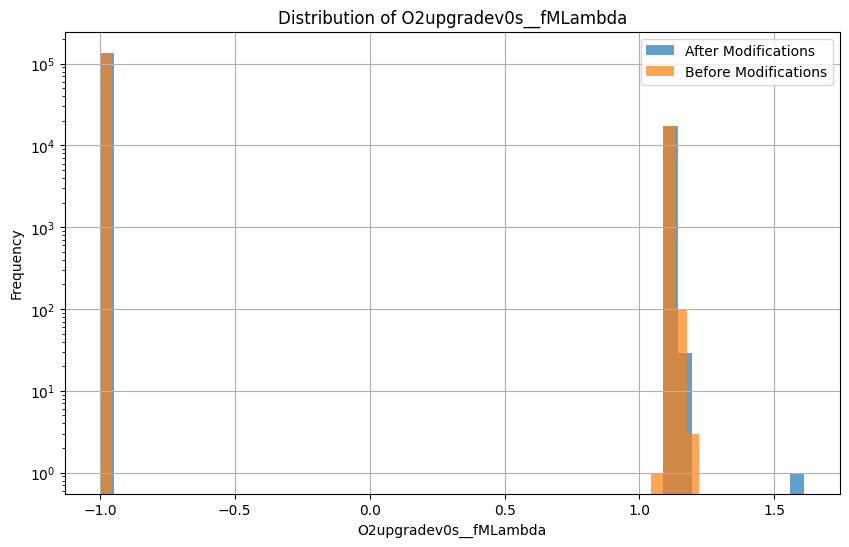

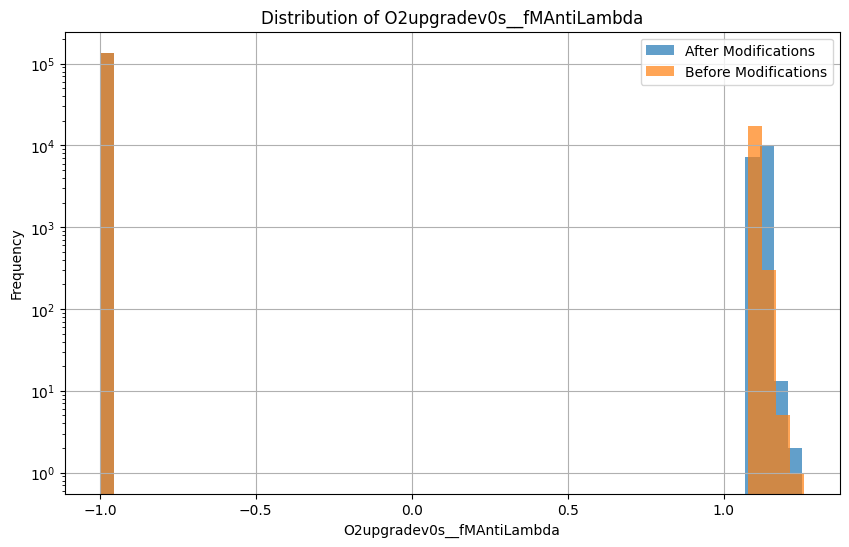

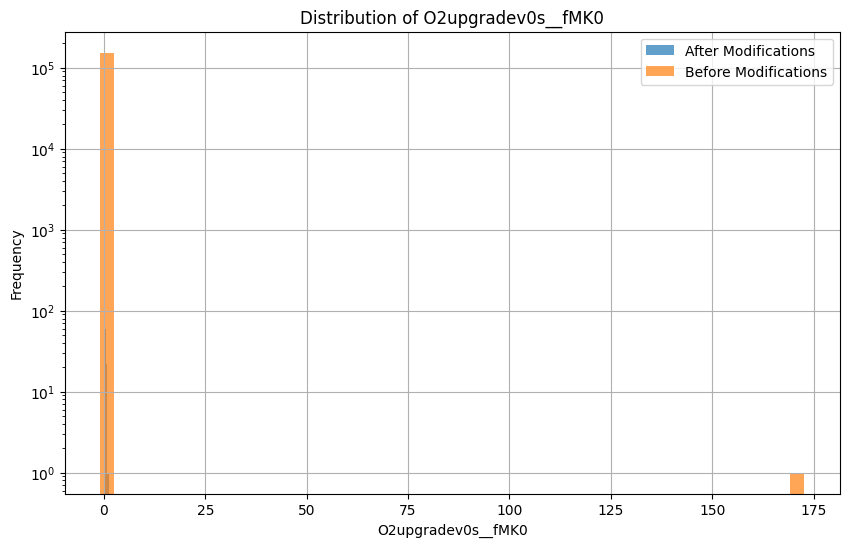

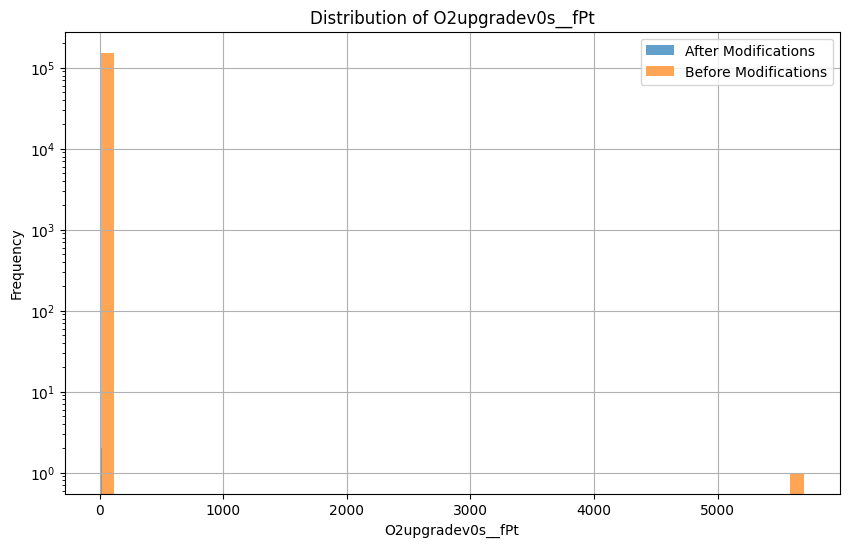

In [18]:
# Plot all columns of the cascades table
for column in df_after_mod["O2upgradev0s"].columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df_after_mod["O2upgradev0s"][column], bins=50, alpha=0.7, log=True, label='After Modifications')
    plt.hist(df_before_mod["O2upgradev0s"][column], bins=50, alpha=0.7, log=True, label='Before Modifications')
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()